In [1]:
import h5py
import helpers
import numpy as np
from pathlib import Path
import torch
import math
from torch.utils import data
from torch.utils.data.dataloader import default_collate

import gc
from accelerate import Accelerator

import os.path as osp
import os

import cloudpickle as pickle
import sys,os,json

from dataloader import *
from nets import *

from nets2_attn import *

%load_ext autoreload
%autoreload 2

# --------------------------------------------------------------------------------------

def save_obj(obj, name):
    with open(name + '.pkl', 'wb') as f:
        pickle.dump(obj, f)
        
def load_obj(name):
    with open(name, 'rb') as f:
        return pickle.load(f)
    

In [2]:
# --------------------------------------------------------------------------------------
# custom log-mse loss



class logMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        
    def forward(self, pred, actual):
        # log-transform the targets
        #actual = transform_inputs(actual, scaling=1e5)

        return torch.log(self.mse(pred, actual))



def log_cosh_loss(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    def _log_cosh(x: torch.Tensor) -> torch.Tensor:
        return x + torch.nn.functional.softplus(-2. * x) - math.log(2.0)
    return torch.mean(_log_cosh(y_pred - y_true))

class LogCoshLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(
        self, y_pred: torch.Tensor, y_true: torch.Tensor
    ) -> torch.Tensor:
        return log_cosh_loss(y_pred, y_true)

# --------------------------------------------------------------------------------------


### READ IN CONFIGS
#config_file_path = sys.argv[1] #'./comparison/configs.json'

config_file_path = "./configs_default2.json"

with open(config_file_path) as f:
        configs = json.load(f)


# model stuff
# HIDDEN_CHANNELS = configs["model_params"][model_type][model_size]["hidden_channels"]
# NUM_LAYERS = configs["model_params"][model_type][model_size]["num_layers"]
# MODEL_NAME = configs["model_params"][model_type][model_size]["name"]
# TEST_BATCHING = configs["model_params"][model_type][model_size]["test_batching"]
        
FILTERS = configs["model_params"]["filters"]
NOISEAMP = configs["model_params"]["noiseamp"]
N_FG = configs["model_params"]["n_fg"]
MODEL_PATH = configs["model_params"]["model_path"]
MODEL_NAME = configs["model_params"]["model_name"]



# # optimizer schedule
LEARNING_RATE = configs["training_params"]["learning_rate"]
BATCH_SIZE = configs["training_params"]["batch_size"]
EPOCHS = int(configs["training_params"]["epochs"])
SCALING = 1e5
#DO_SCHEDULER = bool(int(configs["training_params"]["do_lr_scheduler"]))
SEED = int(configs["training_params"]["seed"])

# # data + out directories
cosmopath = configs["training_params"]["cosmopath"]
galpath = configs["training_params"]["galpath"]


MODEL_DIR = configs["model_params"]["model_dir"]
LOAD_DIR = configs["model_params"]["load_dir"]
LOAD_MODEL = bool(configs["training_params"]["load_model"])

TRAIN_WITH_CACHE = False
#ADD_NOISE = configs["training_params"]["add_noise"]
ADD_NOISE = True

if not os.path.exists(MODEL_DIR):
   # Create a new directory if it does not exist
   os.makedirs(MODEL_DIR)
   print("created new directory", MODEL_DIR)

# ### CONSTRUCT MODEL NAME AND OUTPUT PATH
# MODEL_NAME += "nc_%d_nlyr_%d"%(HIDDEN_CHANNELS, NUM_LAYERS)
# MODEL_PATH = MODEL_DIR + MODEL_NAME
# LOAD_PATH = LOAD_DIR + MODEL_NAME



# --------------------------------------------------------------------------------------
    
print("LOADING DATA AND INITIALISING DATALOADERS")

# fix random seed
np.random.seed(SEED)
torch.manual_seed(SEED)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cosmofiles = os.listdir(cosmopath)
galfiles = os.listdir(galpath)

# save the filenames 
#save_obj(cosmofiles, "/data101/makinen/hirax_sims/dataloader/cosmofiles")
#save_obj(galfiles, "/data101/makinen/hirax_sims/dataloader/galfile")


cosmofiles = [cosmopath + p for p in cosmofiles]
galfiles =  [galpath + p for p in galfiles]


# random mask for train/val split
mask = np.random.rand(len(cosmofiles)) < 0.9
train_cosmo_files = list(np.array(cosmofiles)[mask])[:configs["training_params"]["num_train"]]
val_cosmo_files = list(np.array(cosmofiles)[~mask])

galmask = np.random.rand(len(galfiles)) < 0.9
train_gal_files = list(np.array(galfiles)[galmask])
val_gal_files = list(np.array(galfiles)[~galmask])

# save the train/val masks
#np.save("/data101/makinen/hirax_sims/dataloader/cosmo_mask", mask)
#np.save("/data101/makinen/hirax_sims/dataloader/gal_mask", galmask)


# --------------------------------------------------------------------------------------


LOADING DATA AND INITIALISING DATALOADERS


In [3]:
N_FG

11

In [4]:

def preprocess_data(x,y):
    
        # split ordering (batch, baseline, freq, ra) = (batch*split, 48, 128, 128)
        # then transpose to (batch*split, freq, ra, baseline)
        x = torch.permute(
            torch.cat(torch.tensor_split(x, split, dim=3)),
            (0, 3, 1, 2)
        )
        y = torch.permute(
                torch.cat(torch.tensor_split(y, split, dim=3)),
                (0, 3, 1, 2)
        )
        # then finally get the real and im parts as channels
        # shape: (batch*split, freq, ra, baseline, Re/Im)
        x = torch.stack([x.real, x.imag], dim=-1)
        y = torch.stack([y.real, y.imag], dim=-1)

        
        # add white noise to the signal
        if ADD_NOISE:
            x += torch.normal(mean=0.0, std=torch.ones(x.shape)*NOISEAMP) #.to(device)
        
        # pass x to the pca
        x = PCALayer(x, N_FG=N_FG)

        x *= 1e5
        y *= 1e5
        
        # log-transformation of input data for network
        #x = transform_inputs(x, scaling=1e5)
        
        # transformation of outputs handled in the loss function
        #y = transform_inputs(y, scaling=1e5)

        
        # get y into same shape as model outputs
        y = torch.permute(y, (0, 4, 2, 1, 3))
        
        return x.to(device),y.to(device)

In [5]:

# --------------------------------------------------------------------------------------


# create train and val datasets and loaders with collate fn

print("INITIALISING dataloaders")
train_dataset = H5Dataset(train_cosmo_files, train_gal_files, use_cache=False)
val_dataset = H5Dataset(val_cosmo_files, val_gal_files, use_cache=False)


train_dataloader = DataLoader(
    train_dataset,
    batch_size=2,  # bigger batch ?
    num_workers=1, # how high can we go ?
    shuffle=False,
    pin_memory=True, # do we need this ?
    #collate_fn=my_collate_fn
)

# the new collate function is quite generic
#loader = DataLoader(demo, batch_size=50, shuffle=True, 
#                    collate_fn=lambda x: tuple(x_.to(device) for x_ in default_collate(x)))

val_dataloader = DataLoader(
    val_dataset,
    num_workers=0,
    shuffle=False,
    pin_memory=True
)


# --------------------------------------------------------------------------------------

# initialise model and accelerator


print("INITIALISING MODEL")
    
# reinitialise the dataloader
# train_dataset = H5Dataset(train_cosmo_files, train_gal_files, use_cache=False)

# #train_dataset.use_cache = False
# #train_dataset.num_cosmo = len(train_dataset.cosmo_cache)

# train_dataloader = DataLoader(
#     train_dataset,
#     batch_size=1,
#     num_workers=1,
#     shuffle=True,
# )


split = 1024 // 128 # 8 chunks per sky simulation


#STEPS_PER_EPOCH = 100 # reshuffle data each time 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#block = BasicBlock(16, 32)
FILTERS = 7
model = UNet3d(BasicBlock, filters=FILTERS, act=smooth_leaky).to(device)
#model = UNet3DWithAttention(in_channels=2, out_channels=2, init_features=FILTERS)


# start up the optimizer
max_norm = 1.0
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# criterion = nn.MSELoss() #logMSELoss()


def log_cosh_loss(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    def _log_cosh(x: torch.Tensor) -> torch.Tensor:
        return x + torch.nn.functional.softplus(-2. * x) - math.log(2.0)
    return torch.mean(_log_cosh(y_pred - y_true))

class LogCoshLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(
        self, y_pred: torch.Tensor, y_true: torch.Tensor
    ) -> torch.Tensor:
        return log_cosh_loss(y_pred, y_true)


criterion = LogCoshLoss()

model_path = MODEL_PATH
model_path += MODEL_NAME
accelerator = Accelerator(project_dir=model_path)

model, optimizer, train_dataloader = accelerator.prepare(
                model, optimizer, train_dataloader)



if LOAD_MODEL:
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
    history = load_obj(MODEL_DIR + MODEL_NAME + "history.pkl")


# --------------------------------------------------------------------------------------



def train(epoch):
    #model.train()

    pbar = tqdm(total=len(train_dataloader), position=0)
    pbar.set_description(f'Training epoch: {epoch:04d}')

    total_loss = total_examples = 0
    
    pbar2 = tqdm(train_dataloader, leave=True, position=0)
    for i,data in enumerate(pbar2):
        optimizer.zero_grad()
        
        
        x,y = data
        x,y = preprocess_data(x.cpu(),y.cpu())
        
        #y *= model.scaling # same playing field as network
        #x *= model.scaling # scaling factor 


        # log-transformation of input data for network

        preds = model(x)
        loss = criterion(preds, y)
        
        accelerator.backward(loss)
        accelerator.clip_grad_norm_(model.parameters(), max_norm)
        
        optimizer.step() 
        #if DO_SCHEDULER:
        #    lr_scheduler.step()

        total_loss += float(loss) #* int(data.train_mask.sum())
        total_examples += 1 #data.shape #int(data.train_mask.sum())
        
        if not TRAIN_WITH_CACHE:
            train_dataloader.dataset.gal_cache = []
            train_dataloader.dataset.cosmo_cache = []
            
        pbar2.set_description("current loss: %.4f"%(total_loss / total_examples))
            
        pbar.update(1)

    pbar.close()
    # dump to save memory
    gc.collect()
    torch.cuda.empty_cache()

    return total_loss / total_examples


@torch.no_grad()
def test(plot=False):
    model.eval()

    total_loss = total_examples = 0

    #pbar = tqdm(total=len(val_dataloader), position=0)

    for i,data in tqdm(enumerate(val_dataloader)):
        #if i % 2 == 0:
        x,y = data
        x,y = preprocess_data(x.cpu(),y.cpu())
                
        preds = model(x)
        loss = criterion(preds, y)

        preds = preds.cpu()
        y = y.cpu()

        total_loss += float(loss) #* int(data.train_mask.sum())
        total_examples += 1 #data.shape #int(data.train_mask.sum())
        
        if plot:
            plt.subplot(131)
            plt.title("truth")
            plt.imshow(y[0, 0, 0, :, :])
            plt.colorbar()

            plt.subplot(132)
            plt.title("network prediction")
            plt.imshow(preds[0, 0, 0, :, :])
            plt.colorbar()
            
            
            plt.subplot(133)
            plt.title("residual")
            plt.imshow(((preds[0, 0, 0, :, :] - y[0, 0, 0, :, :])))
            plt.colorbar()
            
            plt.show()
    
    val_dataloader.dataset.cosmo_cache = []
    val_dataloader.dataset.gal_cache = []

    return total_loss / total_examples

INITIALISING dataloaders
INITIALISING MODEL


In [6]:
import gc
gc.collect()

torch.cuda.empty_cache()

In [7]:
FILTERS, N_FG

(7, 11)

In [8]:
model_path = "/data101/makinen/hirax_sims/accelerator/pca11_net_12_09"

In [50]:
EPOCHS

25

In [9]:
# --------------------------------------------------------------------------------------
# run the training loop
    
print("STARTING TRAINING LOOP")


gc.collect()


# training history

history = {
    "train_loss": [],
    "val_loss": [],
    "test_loss": [],
    "losses": []
}

best_loss = np.inf

accelerator.save_state(model_path)

# training loop
for epoch in range(1, EPOCHS + 1):

    loss = train(epoch)
    loss = float(loss)

    val_loss = float(test())


    if val_loss < best_loss:

        best_loss = val_loss
        accelerator.save_model(model, model_path)
        accelerator.save_state(model_path)

    # save history
    history["train_loss"].append(loss)
    history["val_loss"].append(val_loss)

    #save_obj(history, MODEL_NAME + "_train_history_inprog") # save locally
    #save_obj(history, model_path + "train_history_inprog")

    # dump to save memory
    gc.collect()
    torch.cuda.empty_cache()
    
    print(f'loss: {loss:.4f}')
    print(f'val loss: {val_loss:.4f}')

# save the history object
#save_obj(history, "train_history")
#save_obj(history, outdir_model + "train_history")
#save_obj(configs, outdir_model + "configs.json")


# should we do the validation checks here ?


STARTING TRAINING LOOP


Training epoch: 0001: 100%|██████████| 362/362 [27:13<00:00,  4.51s/it]
84it [03:33,  2.54s/it]


loss: 0.0317
val loss: 0.0243


Training epoch: 0002: 100%|██████████| 362/362 [23:08<00:00,  3.83s/it]
84it [03:32,  2.54s/it]


loss: 0.0234
val loss: 0.0225


...

loss: 0.0219
val loss: 0.0218


Training epoch: 0005: 100%|██████████| 362/362 [37:00<00:00,  6.13s/it]
84it [05:04,  3.62s/it]


loss: 0.0211
val loss: 0.0214


current loss: 0.0186:  19%|█▉        | 70/362 [09:47<40:51,  8.40s/it]  


KeyboardInterrupt: 

In [10]:
history

{'train_loss': [0.031747633894874575,
  0.023403325236469343,
  0.021775528083642873,
  0.021859915325037352,
  0.021087926192445813],
 'val_loss': [0.024293201620734874,
  0.02245036776488026,
  0.02188581751570815,
  0.021770341366174676,
  0.021398087808241446],
 'test_loss': [],
 'losses': []}

In [209]:
model_path

'/data101/makinen/hirax_sims/accelerator/default_lr_12_11_2'

In [11]:
from copy import deepcopy
model_trained = deepcopy(model)

In [210]:
#accelerator.save_model(model, "/data101/makinen/hirax_sims/accelerator/pca11_net")
#accelerator.save_state("/data101/makinen/hirax_sims/accelerator/pca11_net")

'/data101/makinen/hirax_sims/accelerator/pca7_net'

In [12]:
torch.cuda.empty_cache()

In [13]:
model_path

'/data101/makinen/hirax_sims/accelerator/pca11_net_12_09'

In [35]:
# load pretrained model here

# prepare and load model

# start up the optimizer
max_norm = 1.0
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

model_path = MODEL_PATH
model_path += MODEL_NAME
accelerator = Accelerator(project_dir=model_path)

model, optimizer, train_dataloader = accelerator.prepare(
                model, optimizer, train_dataloader)

accelerator.load_state(model_path)


#if LOAD_MODEL:
#    model.load_state_dict(torch.load(MODEL_PATH))
#    model.eval()
#    history = load_obj(MODEL_DIR + MODEL_NAME + "history.pkl")


# accelerator.load_state

In [36]:
model

UNet3d(
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv3d(2, 7, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), padding_mode=circular)
      (bn1): BatchNorm3d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): smooth_leaky(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv3d(7, 7, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), padding_mode=circular)
      (bn1): BatchNorm3d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): smooth_leaky(inplace=True)
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      (conv1): Conv3d(7, 14, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), padding_mode=circular)
      (bn1): BatchNorm3d(14, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): smooth_leaky(inplace=True)
    )
  )
  (layer3): Sequential(
    (0): BasicBlock(
      (conv1): Conv3d(14, 14, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=

# plotting stuff

In [14]:
#from plot_metrics import *

from astropy.cosmology import FlatLambdaCDM
from astropy import units
from astropy import constants as consts
import numpy as np

from scipy.signal.windows import blackmanharris
import matplotlib.pyplot as plt

cosmology = FlatLambdaCDM(H0=100, Om0=0.3) # H0=100 km/s/Mpc so in h units
nu_21 = 1420.405751768*units.MHz

def z21(freq):
    freq = units.Quantity(freq, unit=units.MHz)
    return (nu_21/freq - 1).value

def k_perpendicular(bl_length, freq):
    freq = units.Quantity(freq, unit=units.MHz)
    bl_length = units.Quantity(bl_length, unit=units.m)
    wl = freq.to('m', equivalencies=units.spectral())
    k_pp = 2*np.pi*np.linalg.norm(bl_length)/wl/cosmology.comoving_transverse_distance(z21(freq))
    return k_pp.to('Mpc^-1')

def delays_from_freqs(freqs):
    freqs = units.Quantity(freqs, unit=units.MHz)
    d = (freqs[1]-freqs[0]).to('ns^-1')
    return np.fft.fftshift(np.fft.fftfreq(len(freqs), d=d))

def k_parallel(delays, freq):
    freq = units.Quantity(freq, unit=units.MHz)
    z = z21(freq)
    eta_to_kh = 2*np.pi*nu_21*cosmology.H(z)/consts.c/(1+z)**2
    k_parallel = (eta_to_kh*delays).to('Mpc^-1')
    return k_parallel
    
def wedge(theta_0, bl_ind, band_center=550*units.MHz):
    
    z = z21(band_center)
    wl = band_center.to('m', equivalencies=units.spectral()).value
    
    bl = baselines[bl_ind, ...]*units.m
    
    k_pp = k_perpendicular(np.linalg.norm(bl), band_center)
    k_par = theta_0.to('rad').value*k_pp*((cosmology.H(z)*cosmology.comoving_transverse_distance(z))/(consts.c*(1+z))).to('').value
    
    return k_par*0.7 # Double check h factor

def baseline_delay_spectrum(data, bl_ind, band_center=550*units.MHz):
    
    #with h5py.File(vis_fname, 'r') as fil:
    #    data = fil['vis'][bl_ind, ...] # bl, freq, ras
    
    data = data[bl_ind]
        
    N = data.shape[0] # Number of freqs
    
    z = z21(band_center)
    eta_to_kh = 2*np.pi*nu_21*cosmology.H(z)/consts.c/(1+z)**2
    
    delays = delays_from_freqs(freqs)
    k_par = k_parallel(delays, band_center)
    window = blackmanharris(N)
    
    delay_spec = np.fft.fftshift(np.abs(np.fft.fft(data*window[:, None], axis=0))**2)*units.K**2
    
    return delays, k_par, delay_spec

def plot_delay_spectrum(data, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays, k_par, delay_spec = baseline_delay_spectrum(data, bl_ind, band_center=band_center)
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    extent = (ras[0], ras[-1], k_par[0].value, k_par[-1].value)
    
    to_plot = np.log10(delay_spec.value[:, ::-1])
    vmin = to_plot.max() - rel_range
    
    im = ax.imshow(to_plot, vmin=vmin, aspect=100, extent=extent, origin='lower', cmap='magma')
    
    wedge_k_pp = wedge(wedge_angle, bl_ind, band_center=band_center)
    ax.axhline(wedge_k_pp.value, color='white', ls='--')
    ax.axhline(-wedge_k_pp.value, color='white', ls='--')
    
    ax.set_xlabel('RA [deg]')
    ax.set_ylabel(r'$k_{\parallel}$ [h Mpc$^{-1}$]')
    
    plt.colorbar(im, label='[K$^2$]')
    
    return fig, to_plot

def plot_delay_spectrum_of_residual(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays, k_par, delay_spec = baseline_delay_spectrum((data1 - data_true), bl_ind, band_center=band_center)
    
    delays, k_par, delay_spec2 = baseline_delay_spectrum((data_true), bl_ind, band_center=band_center)

    delay_spec /= delay_spec2
    
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    extent = (ras[0], ras[-1], k_par[0].value, k_par[-1].value)
    
    to_plot = delay_spec.value[:, ::-1] #np.log10(delay_spec.value[:, ::-1])
    vmin = to_plot.max() - rel_range
    
    im = ax.imshow(to_plot, aspect=100, vmin=-2, vmax=2, extent=extent, origin='lower', cmap="coolwarm")
    
    wedge_k_pp = wedge(wedge_angle, bl_ind, band_center=band_center)
    ax.axhline(wedge_k_pp.value, color='white', ls='--')
    ax.axhline(-wedge_k_pp.value, color='white', ls='--')
    
    ax.set_xlabel('RA [deg]')
    ax.set_ylabel(r'$k_{\parallel}$ [h Mpc$^{-1}$]')
    
    plt.colorbar(im, label='error')
    
    return (fig,delay_spec)

def plot_residual_of_delay_spectrum(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays1, k_par, delay_spec1 = baseline_delay_spectrum(data1, bl_ind, band_center=band_center)
    
    delays2, k_par, delay_spec2 = baseline_delay_spectrum(data_true, bl_ind, band_center=band_center)
    
    delay_spec = (delay_spec1 - delay_spec2) / delay_spec2
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    extent = (ras[0], ras[-1], k_par[0].value, k_par[-1].value)
    
    #to_plot = np.log10(delay_spec.value[:, ::-1])
    to_plot = delay_spec.value[:, ::-1]
    vmin = to_plot.max() - rel_range
    
    im = ax.imshow(to_plot, aspect=100, vmin=-2, vmax=2, extent=extent, origin='lower', cmap="coolwarm")
    
    wedge_k_pp = wedge(wedge_angle, bl_ind, band_center=band_center)
    ax.axhline(wedge_k_pp.value, color='white', ls='--')
    ax.axhline(-wedge_k_pp.value, color='white', ls='--')
    
    ax.set_xlabel('RA [deg]')
    ax.set_ylabel(r'$k_{\parallel}$ [h Mpc$^{-1}$]')
    
    plt.colorbar(im, label='error')
    
    return (fig,delay_spec)

/softs/intelpython/intelpython3-2022.2.1.17274/intelpython/python3.9/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.25.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# check saliency on test set

In [15]:
# apply network to the test simulation

def apply_network(x, y):
    
    x,y = preprocess_data(x,y)
    
    x = x.to(device)
    y = y.to(device)
    m = model.to(device)
    
    # inverse-transform taken care of
    #x = transform_inputs(x)
    preds = m(x).cpu()
    #preds = inv_transform_inputs(preds)
    #x = inv_transform_inputs(x)

    #print(m(x).cpu().sum())

    y = (y).cpu().detach().numpy()
    preds = (preds).detach().numpy()
    x = x.cpu().detach().numpy()
    
    return x,y,preds

In [16]:
gpath = "/data101/makinen/hirax_sims/more_baselines/galaxy_gaussian_pb/"
cpath = "/data101/makinen/hirax_sims/cosmo_test_set/"
(xtest, ytest), testcosmo = val_dataset.load_sim_and_cosmology(cosmo_path = cpath + "cosmo_H0_pl18_vis_97.h5" , 
                                   gal_path = gpath + "galaxy_gsm_vis_81.h5")



x, y, preds = apply_network(xtest, ytest)

In [17]:
# load in a data vector
test_cosmo = h5py.File("/data101/makinen/hirax_sims/cosmo_gaussian_pb/cosmo_H0_60p894_vis_0.h5")
baselines = np.array(test_cosmo['/index_map/baselines/'])

# split ordering (batch, baseline, freq, ra) = (batch*split, 48, 128, 128)
# then transpose to (batch*split, freq, ra, baseline)

preds.shape, y.shape

# inputs to delay spectrum code need to be rearranged to
# (baseline, freq, ra)

num_base = 48
num_freq = 128

pca_pred = x.transpose((2, 4, 0, 3, 1)).reshape(48, num_freq, -1, 2) #/ 1e5
net_pred = preds.transpose((2, 4, 0, 3, 1)).reshape(48, num_freq, -1, 2) #/ 1e5
cosmo = y.transpose((2, 4, 0, 3, 1)).reshape(48, num_freq, -1, 2) #/ 1e5


pca_pred = pca_pred[..., 0] + pca_pred[..., 1]*1j
net_pred = net_pred[..., 0] + net_pred[..., 1]*1j
cosmo = cosmo[..., 0] + cosmo[..., 1]*1j

/tmp/ipykernel_853369/1654540769.py:3: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  baselines = np.array(test_cosmo['/index_map/baselines/'])


In [18]:
ibase = 47
freq_edges=np.linspace(500, 600, 128 + 1)
freqs = freq_edges[:-1] + np.diff(freq_edges[:2])[0] / 2

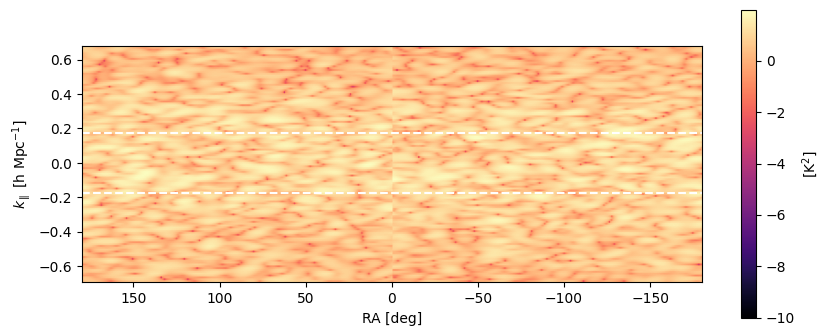

In [19]:
_ = plot_delay_spectrum(cosmo, bl_ind=ibase)

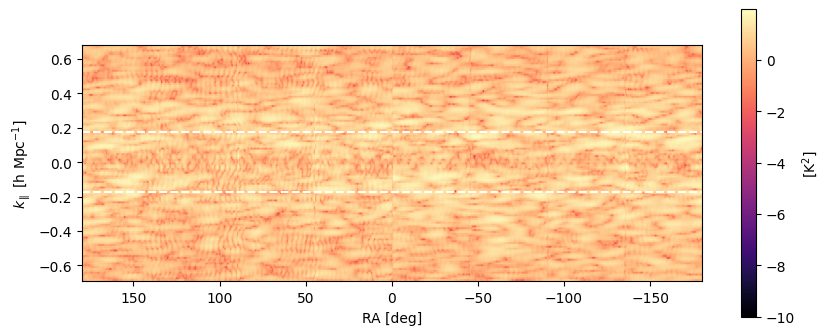

In [20]:
_ = plot_delay_spectrum(net_pred, bl_ind=ibase)

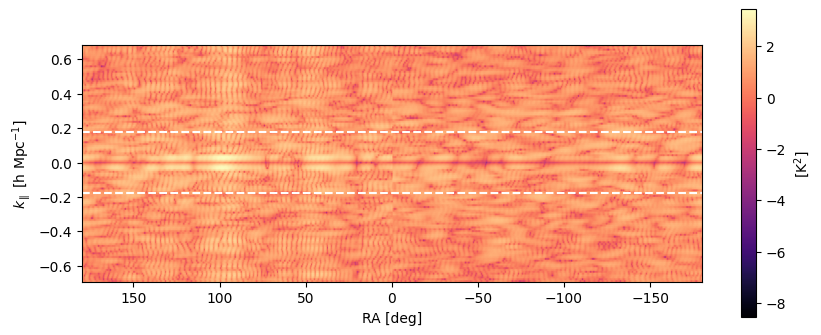

In [21]:
(_, pca_delay_spec) = plot_delay_spectrum(pca_pred, bl_ind=ibase)

In [40]:
ibase = 5

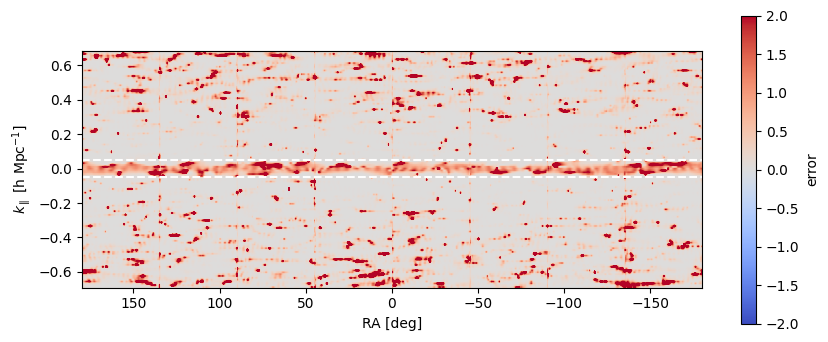

In [41]:
(fig,res_delay_spec_unet) = plot_delay_spectrum_of_residual(net_pred, cosmo, bl_ind=ibase, rel_range=3)

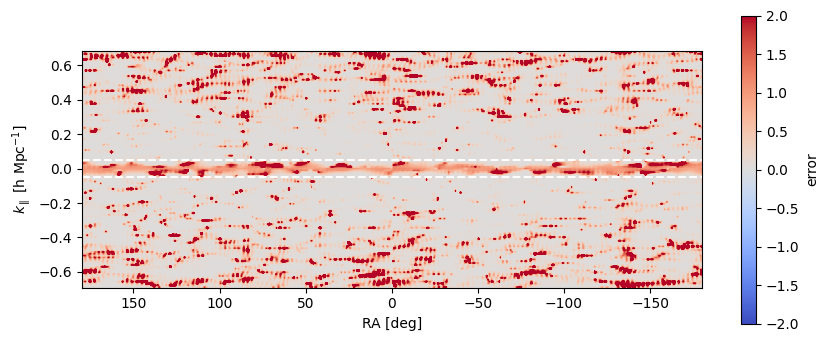

In [42]:
(_, res_delay_spec_pca) = plot_delay_spectrum_of_residual(pca_pred, cosmo, bl_ind=ibase, rel_range=3)

In [32]:
pca_pred.shape

(48, 128, 1024)

In [43]:
def delay_spectrum_res_1D(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays1, k_par, delay_spec1 = baseline_delay_spectrum(data1, bl_ind, band_center=band_center)
    delays2, k_par, delay_spec2 = baseline_delay_spectrum(data_true, bl_ind, band_center=band_center)
    
    delay_spec = (delay_spec1 - delay_spec2) / delay_spec2
    
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    return np.mean(delay_spec, -1), k_par

In [44]:
pca_res_spec,kpar = delay_spectrum_res_1D(pca_pred, cosmo, bl_ind=ibase)
unet_res_spec,kpar = delay_spectrum_res_1D(net_pred, cosmo, bl_ind=ibase)

In [45]:
#N_FG=11

Text(0, 0.5, '$\\frac{P_{\\rm pred} - P_{\\rm cosmo}}{P_{\\rm cosmo}}$')

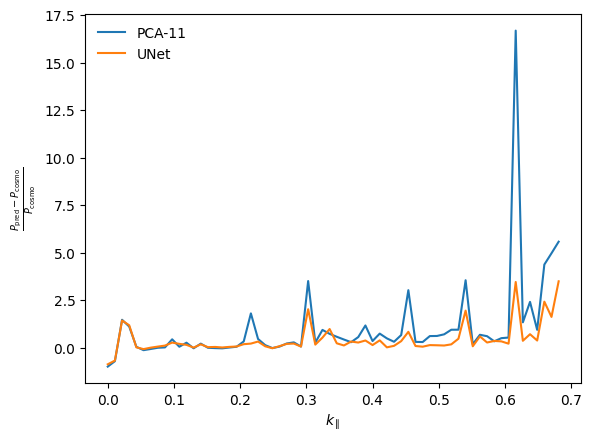

In [46]:
nyquist = 128 // 2

plt.plot(kpar[nyquist:], pca_res_spec[nyquist:], label="PCA-%d"%(N_FG))
plt.plot(kpar[nyquist:], unet_res_spec[nyquist:], label="UNet")
#plt.yscale('log')
plt.legend(framealpha=0.0)
plt.xlabel(r"$k_\parallel$")
plt.ylabel(r"$\frac{P_{\rm pred} - P_{\rm cosmo}}{P_{\rm cosmo}}$")
#plt.ylim(-10, 10)

In [47]:
def residual_delay_spec_1D(data1, data_true, bl_ind, band_center=550*units.MHz, wedge_angle=90*units.deg, rel_range=12):
    
    delays, k_par, delay_spec = baseline_delay_spectrum((data1 - data_true), bl_ind, band_center=band_center)
    delays, k_par, delay_spec2 = baseline_delay_spectrum((data_true), bl_ind, band_center=band_center)
    delay_spec /= delay_spec2
    ras = np.linspace(180, -180, delay_spec.shape[1] + 1)
    
    return np.mean(delay_spec, -1), k_par

In [48]:
pca_spec_res,kpar = residual_delay_spec_1D(pca_pred, cosmo, bl_ind=ibase)
unet_spec_res,kpar = residual_delay_spec_1D(net_pred, cosmo, bl_ind=ibase)

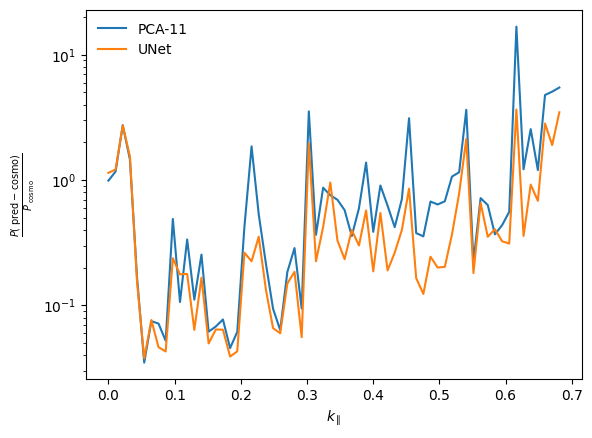

In [49]:
nyquist = 128 // 2

plt.plot(kpar[nyquist:], pca_spec_res[nyquist:], label='PCA-%d'%(N_FG))
plt.plot(kpar[nyquist:], unet_spec_res[nyquist:], label='UNet')
plt.ylabel(r"$\frac{P({\ \rm pred} - {\rm cosmo})}{P_{\ \rm cosmo}}$")
plt.xlabel(r"$k_\parallel$")
plt.legend(framealpha=0.0)
plt.yscale('log')

# train second moment for posterior variance